# 05e — Epic-modell med 3 klasser (epic/medium/thin)
Testar om en riktig medium-klass löser "hålet i mitten"-problemet bättre än binär klassificering eller regression gjorde.

In [87]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR   = 'data/epic_dataset'
IMG_SIZE   = (178, 178)
BATCH_SIZE = 32
MODEL_OUT  = 'models/epic_detector_3class_3.keras'

def count_images(folder):
    return sum(1 for root, dirs, files in os.walk(folder) for f in files
               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')))

print('TensorFlow:', tf.__version__)
print(f"Epic:   {count_images(os.path.join(DATA_DIR, 'epic'))}")
print(f"Medium: {count_images(os.path.join(DATA_DIR, 'medium'))}")
print(f"Thin:   {count_images(os.path.join(DATA_DIR, 'thin'))}")

TensorFlow: 2.16.2
Epic:   1440
Medium: 704
Thin:   1075


## Ladda dataset
`label_mode='categorical'` ger one-hot-kodade etiketter (krävs för 3+ klasser).

In [88]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print('Klasser (i denna ordning):', class_names)

Found 3218 files belonging to 3 classes.
Using 2575 files for training.
Found 3218 files belonging to 3 classes.
Using 643 files for validation.
Klasser (i denna ordning): ['epic', 'medium', 'thin']


## Class weights
Medium är en mycket mindre klass (300 vs tusentals) — här behövs class_weight på riktigt, till skillnad från den milda obalansen vi hade i mustasch-detektorn.

In [89]:
counts = {
    name: count_images(os.path.join(DATA_DIR, name))
    for name in class_names
}
total = sum(counts.values())
n_classes = len(class_names)

class_weight = {
    i: total / (n_classes * counts[name])
    for i, name in enumerate(class_names)
}

print('Antal per klass:', counts)
print('Class weights:', class_weight)

Antal per klass: {'epic': 1440, 'medium': 704, 'thin': 1075}
Class weights: {0: 0.7451388888888889, 1: 1.5241477272727273, 2: 0.998139534883721}


## Bygg modellen
Samma CNN som `05`, men `Dense(3, activation='softmax')` istället för `Dense(1, activation='sigmoid')`.

In [90]:
def build_model(n_classes):
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.03),
        tf.keras.layers.RandomZoom(0.05),
        tf.keras.layers.RandomContrast(0.10),
    ])

    model = tf.keras.Sequential([
        data_augmentation,
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(256, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(n_classes, activation='softmax')
    ])
    return model


model = build_model(n_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

print('Modell byggd!')

Modell byggd!


## Träna

In [91]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop],
    class_weight=class_weight
)

results = model.evaluate(val_ds)
print(f'\nAccuracy: {results[1]*100:.1f}%')

Epoch 1/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 35s 411ms/step - accuracy: 0.4920 - loss: 1.0055 - val_accuracy: 0.6641 - val_loss: 0.7079
Epoch 2/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 35s 428ms/step - accuracy: 0.7169 - loss: 0.6768 - val_accuracy: 0.7729 - val_loss: 0.5264
Epoch 3/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 35s 427ms/step - accuracy: 0.7553 - loss: 0.5944 - val_accuracy: 0.7994 - val_loss: 0.4673
Epoch 4/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 413ms/step - accuracy: 0.7922 - loss: 0.5329 - val_accuracy: 0.7745 - val_loss: 0.5217
Epoch 5/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 410ms/step - accuracy: 0.8023 - loss: 0.5215 - val_accuracy: 0.7683 - val_loss: 0.5152
Epoch 6/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 411ms/step - accuracy: 0.8151 - loss: 0.4809 - val_accuracy: 0.8227 - val_loss: 0.4395
Epoch 7/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 407ms/step - accuracy: 0.8225 - loss: 0.4631 - val_accuracy: 0.7947 - val_loss: 0.4620
Epoch 8/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 407ms/step - accuracy: 0.8260 - loss: 0.4429 - val_accu

## Utvärdering — 3-klass confusion matrix

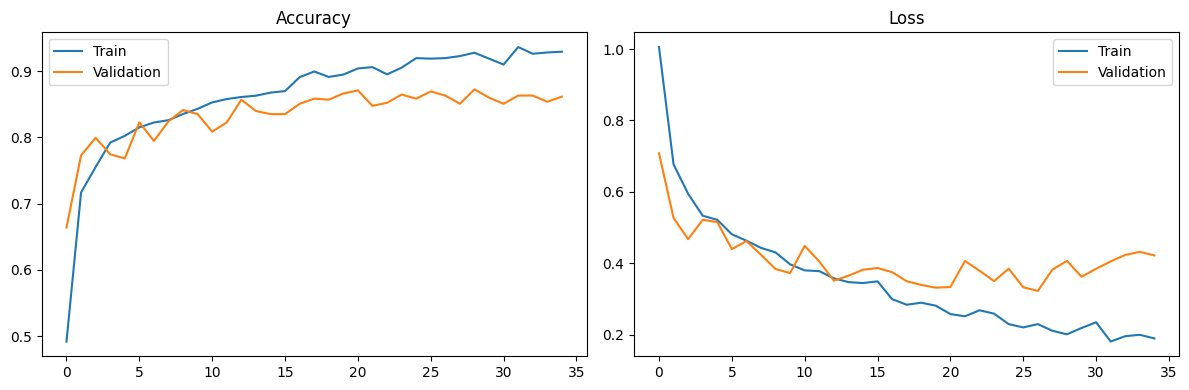

2026-06-28 04:07:40.986232: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


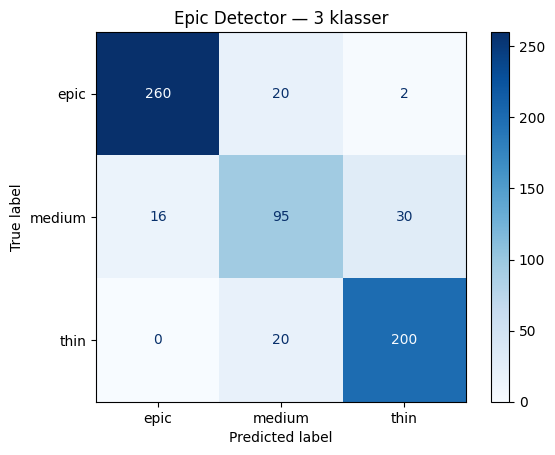

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

y_true, y_pred = [], []
for images, labels_batch in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(values_format='d', cmap='Blues')
plt.title('Epic Detector — 3 klasser')
plt.show()

## Testa viktad poängformel på valideringsdata
`score = P(epic)*100 + P(medium)*50 + P(thin)*0` — kolla om vi nu får en jämnare spridning.

2026-06-28 01:54:19.678304: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


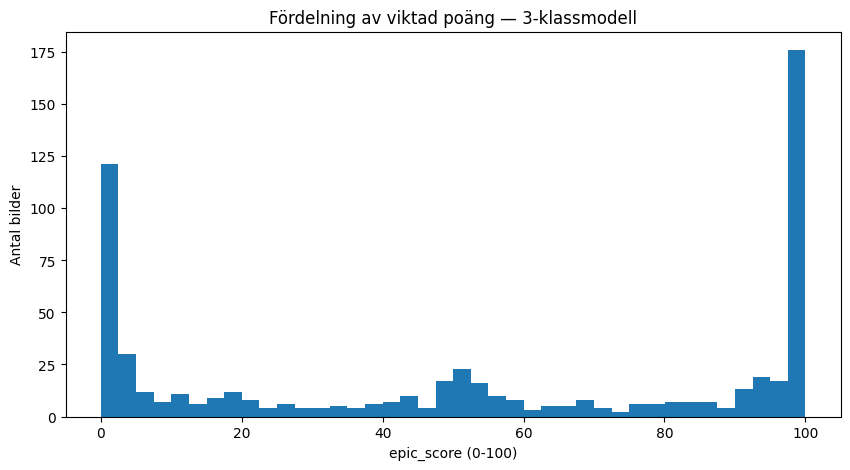

Andel mellan 30-70 (mellanzonen): 21.3%


In [85]:
epic_idx   = class_names.index('epic')
medium_idx = class_names.index('medium')
thin_idx   = class_names.index('thin')

all_scores = []
for images, labels_batch in val_ds:
    preds = model.predict(images, verbose=0)
    scores = preds[:, epic_idx] * 100 + preds[:, medium_idx] * 50 + preds[:, thin_idx] * 0
    all_scores.extend(scores)

all_scores = np.array(all_scores)

plt.figure(figsize=(10, 5))
plt.hist(all_scores, bins=40)
plt.xlabel('epic_score (0-100)')
plt.ylabel('Antal bilder')
plt.title('Fördelning av viktad poäng — 3-klassmodell')
plt.show()

print(f'Andel mellan 30-70 (mellanzonen): {((all_scores >= 30) & (all_scores <= 70)).mean()*100:.1f}%')

## Spara

In [93]:
os.makedirs('models', exist_ok=True)
model.save(MODEL_OUT)
print(f'Sparad: {MODEL_OUT}')

Sparad: models/epic_detector_3class_3.keras
